In [23]:
import numpy as np 
import sklearn
import torch
from sklearn.datasets import load_sample_images
import matplotlib.pyplot as plt

In [24]:
plt.rc('font', size=14)
plt.rc("axes", titlesize=14, labelsize=12)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=12)
plt.rc("ytick", labelsize=12)

#### IMPLEMENTING CONVOLUTIONAL LAYERS WITH PYTORCH

##### sklearn.datasets class contains a lot of toy dataset for training/evaluation purposes
- notable ones are `make blobs dataset`, `make noon`
- `load_sample_image()` returns a dictionary of python lists of images, images labels and descriptions 
- The `images` can be used for data manipulations

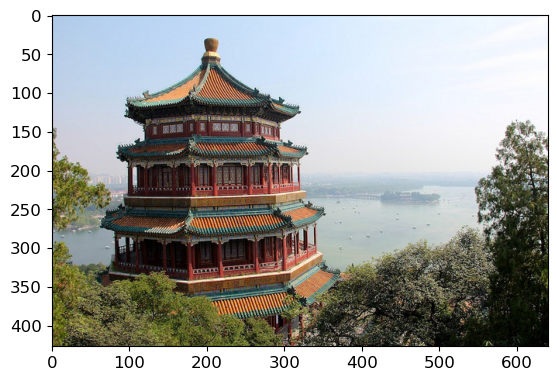

In [25]:
## Visualizing the dataset
data = load_sample_images()["images"]
plt.imshow(data[0])

In [26]:
## np.stack() convert data from python list to numpy to use methods like .shape
## it also create a batch of 2 images so the shape will be (batch, W, H, Channel)
data = np.stack(data)
data = torch.from_numpy(data).type(torch.float)/ 255.0

data.shape


torch.Size([2, 427, 640, 3])

- Let's permute the dimensions from `[batch, height, width, channels]` to `[batch, channels, height, width]`, as PyTorch expects that

In [27]:

data = data.permute(0, 3, 1, 2)
data.shape
    

torch.Size([2, 3, 427, 640])

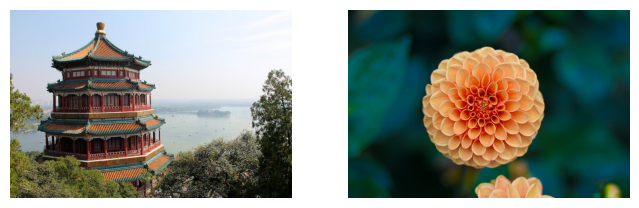

In [28]:
def plot_image(image):
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

plt.figure(figsize=(8, 4))
for index, img in enumerate(data):
    plt.subplot(1, 2, index+1)
    plot_image(img)

In [29]:
import torchvision
import torchvision.transforms.v2 as T 
from torchvision.transforms import v2

transform = v2.Compose([
    v2.CenterCrop((50, 120))
])

image_data_cropped = transform(data)
image_data_cropped.shape

torch.Size([2, 3, 50, 120])

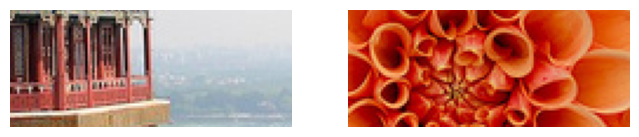

In [30]:
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plot_image(image_data_cropped[0])
plt.subplot(1, 2, 2)
plot_image(image_data_cropped[1])

In [31]:
import torch.nn as nn

In [32]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7 )
f_map = conv_layer(image_data_cropped)


In [33]:
f_map.shape

torch.Size([2, 32, 44, 114])

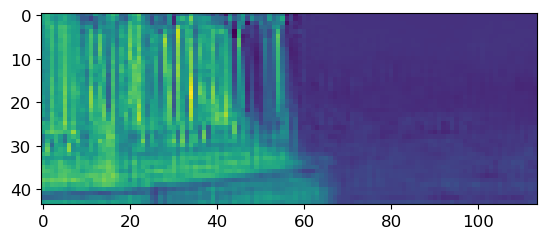

In [34]:

## Visualizing color channels
channel = f_map[0]  
plt.imshow(channel[0].detach(), cmap='viridis')  # show first channel


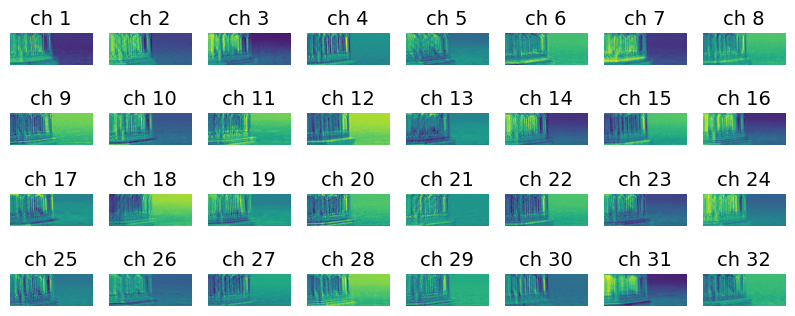

In [35]:
import math
C = channel.shape[0]
cols = 8
rows = math.floor(C/cols)
# print(rows)
plt.figure(figsize=(10, 4))

for idx in range(1, C+1):
    plt.subplot(rows, cols, idx)
    plt.imshow(channel[idx-1].detach().numpy(), cmap="viridis")
    plt.title(f'ch {idx}')
    plt.axis(False)



    



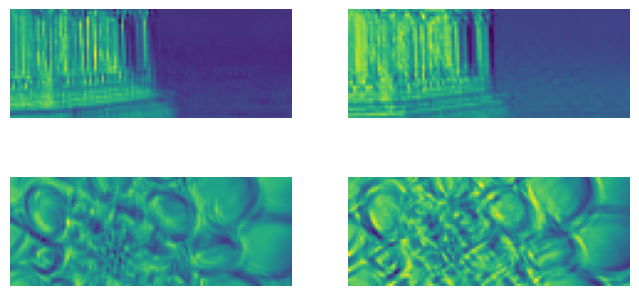

In [36]:
plt.figure(figsize=(8, 4))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(f_map[image_idx, fmap_idx].detach(), cmap="viridis")
        plt.axis("off")

plt.show()

-  randomly generated filters typically act like edge detectors, which is great since that's a useful tool in image processing, and that's the type of filters that a convolutional layer typically starts with. Then, during training, it gradually learns improved filters to recognize useful patterns for the task.
- lets add zeros to pad the image

In [37]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding="same")

In [38]:
image_data_cropped.shape

torch.Size([2, 3, 50, 120])

In [39]:
f_maps = conv_layer(image_data_cropped)
f_maps.shape

torch.Size([2, 32, 50, 120])

In [40]:
# extra code – shows the output shape when we set strides=2
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, stride=2,
                       padding=3)
f_maps = conv_layer(image_data_cropped)
f_maps.shape

torch.Size([2, 32, 25, 60])

### lets look at the layer parameters
- `layer.weights`
- `layer.bias`

In [41]:
print(conv_layer.weight.shape)
print(conv_layer.bias.shape)

torch.Size([32, 3, 7, 7])
torch.Size([32])


- The weight has shape `[output_channels, input_channels, kernel_height, kernel_width] `. The bias tensor is
1D, with shape [output_channels]. 
- The number of output channels is equal to the number of output feature maps which is also equal to the number of filters
- NB: the kernel shape does not include `height` and `width`of the input images, this is because all the neurons in the output feature map shares the same weight
- it is important to add `activation layer` after each convolution layer because convolution is a linear operation
 and without activation function we can't  capture `complex patterns`
- Both the weights and bias parameters are initialized ramdomly, using a uniform distribution similar to the one in `nn.Linear` between $- \frac{1}{\sqrt(k)}  and + \frac{1}{\sqrt(k)}$ where K is the $fan_in$
- in `nn.Conv2d`, $k=f_h \times f_w \times f_n $
- $f_h$: height of kernel $f_w$: width of kernel $f_n$: number of input channels
- In most cases, you will generally want to reinitialize the weights based on the activation function
- For the `ReLU` activation function, we should reinitialize the `weights`, the `bias`can be reinitialized to all zeros
- Although time consuming, we can always use cross validation to find the best parameters for our convolutional networks

- ##### extra code – shows how to use the torch.nn.functional.conv2d() operation

In [42]:
import torch.nn.functional as F
torch.manual_seed(42)

filters = torch.randn([2, 3, 7, 7])
biases = torch.zeros([2])
f_maps = F.conv2d(image_data_cropped, filters, biases, stride=1, padding="same")

f_maps.shape

torch.Size([2, 2, 50, 120])

- #### Let's manually create two filters full of zeros, except for a vertical line of 1s in the first filter, and a horizontal one in the second filter 

- #### The two output feature maps highlight vertical lines and horizontal lines, respectively.


In [43]:
filters = torch.zeros([2, 3, 7,7])
filters[0, :, : , 3]=1
filters[1, :, 3, : ] = 1

f_maps = F.conv2d(image_data_cropped, filters, biases, stride=1, padding="same")

f_maps.shape


torch.Size([2, 2, 50, 120])

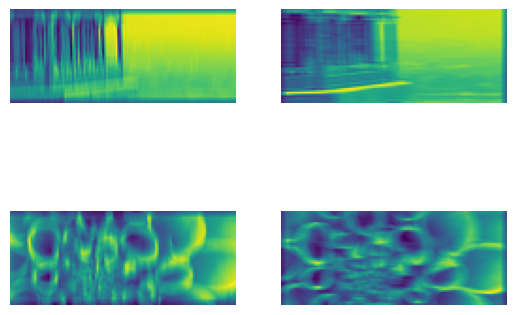

In [44]:
for img_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2,2, img_idx*2 + fmap_idx+1)
        plt.imshow(f_maps[img_idx, fmap_idx])
        plt.axis("off")
        

#### Pooling layers
- ##### IMPLEMENTING POOLING LAYERS WITH PYTORCH

In [46]:
max_pool= nn.MaxPool2d(kernel_size=2)
output_max = max_pool(image_data_cropped)

In [47]:
avg_pool = nn.AvgPool2d(kernel_size=2)
output_avg = avg_pool(image_data_cropped)

(np.float64(-0.5), np.float64(59.5), np.float64(24.5), np.float64(-0.5))

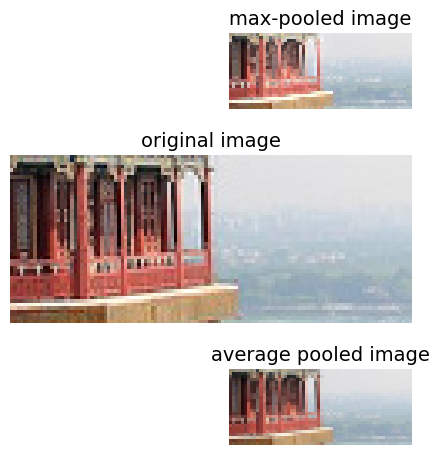

In [57]:
fig = plt.figure(figsize=(8,8))
ax1 = plt.subplot2grid(shape=(2, 3), loc=(0, 1), rowspan=2, colspan=2 )
ax1.imshow(image_data_cropped[0].permute(1,2,0))
ax1.set_title("original image")
ax1.axis('off')

ax2 = plt.subplot2grid(shape=(2, 3), loc=(0,2))
ax2.imshow(output_max[0].permute(1,2,0))
ax2.set_title("max-pooled image")
ax2.axis('off')

ax3 = plt.subplot2grid(shape=(2, 3), loc=(1,2))
ax3.imshow(output_avg[0].permute(1,2,0))
ax3.set_title("average pooled image")
ax3.axis('off')

In [ ]:
class DepthMaxPool2d(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride if stride is not None else kernel_size
        self.padding = padding
        
    def forward(self, inputs):
        batch, channels,height, width = inputs.shape
        Z= input.view(batch, channels, height * width) #merge spatial dimension
        Z = Z.permute(0, 2, 1) #switch spatial and channel dim
        Z= F.max_pool1d(Z, kernel_size=self.kernel_size, stride=self.stride, padding=self.padding) #compute max_pool
        Z=Z.permute(0, 2, 1) #switch batch spatial and channel dim
        return Z.view(batch, -1, height, width) #unmerge spatial dimension
        